1. Wczytywanie danych i podział (TARGET_BUSINESS_LOUNGE)...
2. Uczenie WERSJI 2.0 dla BUSINESS LOUNGE (Lasso L1 i Płytsze Drzewa)...
(Info: Waga klasy pozytywnej wynosi: 657.9)
3. Analiza Progu (Cel biznesowy: Precyzja ~10%)...

--- RAPORT MODELU BUSINESS LOUNGE v2 (Próg: 94.2%) ---
                 precision    recall  f1-score   support

Brak Lounge (0)       1.00      1.00      1.00    105430
Kupi Lounge (1)       0.10      0.07      0.08       160

       accuracy                           1.00    105590
      macro avg       0.55      0.53      0.54    105590
   weighted avg       1.00      1.00      1.00    105590


--- EFEKT EKSTREMALNEGO LASSO (L1=50) DLA BUSINESS LOUNGE ---
Liczba kolumn na wejściu: 468
Kolumny użyte (przetrwały): 168
Kolumny wyzerowane (usunięte): 300

--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---


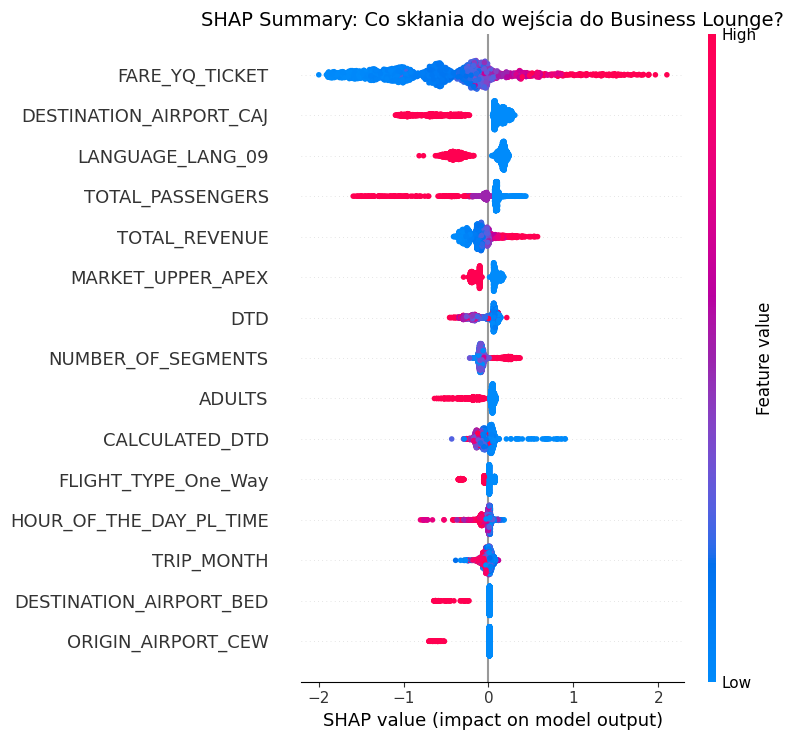

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import shap

warnings.filterwarnings('ignore')

print("1. Wczytywanie danych i podział (TARGET_BUSINESS_LOUNGE)...")
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

# Zmieniamy cel na Business Lounge (sprawdź dokładną nazwę kolumny w swoich danych!)
y = df_final['TARGET_BUSINESS_LOUNGE'] 
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)

# Oczyszczanie nazw
X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("2. Uczenie WERSJI 2.0 dla BUSINESS LOUNGE (Lasso L1 i Płytsze Drzewa)...")
# Wyrównanie klas
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"(Info: Waga klasy pozytywnej wynosi: {pos_weight:.1f})")

xgb_model_lounge_v2 = xgb.XGBClassifier(
    n_estimators=300,          
    learning_rate=0.03,        
    max_depth=4,               
    colsample_bytree=0.8,      
    scale_pos_weight=pos_weight, 
    reg_alpha=50,              # POTĘŻNE LASSO (L1) - odrzucamy szum
    reg_lambda=10,             
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model_lounge_v2.fit(X_train, y_train)

print("3. Analiza Progu (Cel biznesowy: Precyzja ~10%)...")
y_probs_lounge_v2 = xgb_model_lounge_v2.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_lounge_v2)

# Celujemy w 10% precyzji
target_precision = 0.10
try:
    optimal_idx = np.where(precisions >= target_precision)[0][0]
    optimal_threshold = thresholds[optimal_idx]
except IndexError:
    optimal_idx = np.argmax(precisions)
    optimal_threshold = thresholds[optimal_idx]

y_pred_lounge_v2 = (y_probs_lounge_v2 >= optimal_threshold).astype(int)

print(f"\n--- RAPORT MODELU BUSINESS LOUNGE v2 (Próg: {optimal_threshold*100:.1f}%) ---")
print(classification_report(y_test, y_pred_lounge_v2, target_names=['Brak Lounge (0)', 'Kupi Lounge (1)']))

# --- EFEKT EKSTREMALNEJ REGULARYZACJI ---
print("\n--- EFEKT EKSTREMALNEGO LASSO (L1=50) DLA BUSINESS LOUNGE ---")
used_features = xgb_model_lounge_v2.get_booster().get_fscore()
num_used = len(used_features)
num_total = X.shape[1]
print(f"Liczba kolumn na wejściu: {num_total}")
print(f"Kolumny użyte (przetrwały): {num_used}")
print(f"Kolumny wyzerowane (usunięte): {num_total - num_used}")

# --- MAGIA SHAP: Kto idzie do VIP Lounge? ---
print("\n--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---")
X_sample = X_test.head(2000)

explainer = shap.TreeExplainer(xgb_model_lounge_v2)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(12, 8))
plt.title('SHAP Summary: Co skłania do wejścia do Business Lounge?', fontsize=14)
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()